## World Happiness Report (2019) - Case: Exploratory Data Analysis, Regression and Classification Modeling

In this notebook, I perform an in-depth analysis of the **World Happiness Report (2019)** dataset. Originally, there are 5 datasets available from 2015 to 2019, but for this case study, we focus exclusively on the 2019 data. This dataset consists of **156 clean rows** (with no missing values), and preliminary Exploratory Data Analysis (EDA) has been conducted to understand its structure. The primary goal is to understand the factors contributing to happiness scores across different countries and to build predictive models.

### Dataset Overview and Key Parameters:

Our dataset includes several crucial parameters for each country:

*   **Country or region:** The name of the country.
*   **Score:** The happiness score, which is the target variable for our **regression models**.
*   **GDP per capital:** The economic output per person, reflecting the economic strength of a country.
*   **Social support:** The extent to which a country's citizens feel they have social support (e.g., family, friends) in times of trouble.
*   **Healthy life expectancy:** The average number of years a person can expect to live in 'full health'.
*   **Freedom to make life choices:** The perceived freedom to choose what one does with their life.
*   **Generosity:** The extent to which a country's citizens are involved in charitable acts.
*   **Perceptions of corruption:** The perceived level of corruption in government and business.
*   **Score_class:** A categorical target variable derived from 'Score' ('Low', 'Medium', 'High'), used for our **classification models**.

### Analytical Logic:

This notebook demonstrates a typical machine learning workflow, moving from data understanding to model evaluation:

1.  **Data Loading and Initial Exploration:** Loading the dataset and performing initial checks (shape, info, descriptive statistics, unique values, missing values).
2.  **Feature Engineering & Visualization:** Creating visualizations (e.g., correlation heatmap, 3D scatter plot) and pivot tables to uncover relationships and patterns within the data, including combining features to understand complex dependencies.
3.  **Data Preprocessing:** Handling categorical variables (One-Hot Encoding) and scaling numerical features to prepare the data for machine learning models.
4.  **Regression Modeling:** Training and evaluating various regression models (Linear Regression, Random Forest, Gradient Boosting) to predict the continuous 'Score'. This includes hyperparameter tuning for optimal performance.
5.  **Classification Modeling:** Transforming the 'Score' into 'Score_class' and then training and evaluating classification models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, KNN) to predict happiness categories. This also involves hyperparameter tuning for each model and detailed evaluation using Accuracy, F1-score, Confusion Matrices, and Classification Reports.

This structured approach aims to provide a clear and logical example of how to tackle a data analysis and machine learning problem, from initial exploration to selecting the best-performing model.

Dataset Source

This dataset is sourced from Kaggle. You can find the original dataset [here](https://www.kaggle.com/datasets/unsdsn/world-happiness).

### **1. Data Loading and Initial Exploration**

In [74]:
from google.colab import files
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
uploaded = files.upload()

Saving 2019.csv to 2019.csv


In [88]:
df = pd.read_csv(io.BytesIO(uploaded['2019.csv']))
df = pd.read_csv('/content/2019.csv')
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [90]:
df.drop('Overall rank', axis=1, inplace=True)

In [91]:
df.shape

(156, 8)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country or region             156 non-null    object 
 1   Score                         156 non-null    float64
 2   GDP per capita                156 non-null    float64
 3   Social support                156 non-null    float64
 4   Healthy life expectancy       156 non-null    float64
 5   Freedom to make life choices  156 non-null    float64
 6   Generosity                    156 non-null    float64
 7   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.9+ KB


In [93]:
df.rename(columns={'GDP per capita': 'GDP per capital'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country or region             156 non-null    object 
 1   Score                         156 non-null    float64
 2   GDP per capital               156 non-null    float64
 3   Social support                156 non-null    float64
 4   Healthy life expectancy       156 non-null    float64
 5   Freedom to make life choices  156 non-null    float64
 6   Generosity                    156 non-null    float64
 7   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.9+ KB


In [94]:
df.describe()

,Score,GDP per capital,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [95]:
for col in df.columns:
    print(f"Unique values for column '{col}':")
    print(df[col].unique())
    print("\n")

Unique values for column 'Country or region':
['Finland' 'Denmark' 'Norway' 'Iceland' 'Netherlands' 'Switzerland'
 'Sweden' 'New Zealand' 'Canada' 'Austria' 'Australia' 'Costa Rica'
 'Israel' 'Luxembourg' 'United Kingdom' 'Ireland' 'Germany' 'Belgium'
 'United States' 'Czech Republic' 'United Arab Emirates' 'Malta' 'Mexico'
 'France' 'Taiwan' 'Chile' 'Guatemala' 'Saudi Arabia' 'Qatar' 'Spain'
 'Panama' 'Brazil' 'Uruguay' 'Singapore' 'El Salvador' 'Italy' 'Bahrain'
 'Slovakia' 'Trinidad & Tobago' 'Poland' 'Uzbekistan' 'Lithuania'
 'Colombia' 'Slovenia' 'Nicaragua' 'Kosovo' 'Argentina' 'Romania' 'Cyprus'
 'Ecuador' 'Kuwait' 'Thailand' 'Latvia' 'South Korea' 'Estonia' 'Jamaica'
 'Mauritius' 'Japan' 'Honduras' 'Kazakhstan' 'Bolivia' 'Hungary'
 'Paraguay' 'Northern Cyprus' 'Peru' 'Portugal' 'Pakistan' 'Russia'
 'Philippines' 'Serbia' 'Moldova' 'Libya' 'Montenegro' 'Tajikistan'
 'Croatia' 'Hong Kong' 'Dominican Republic' 'Bosnia and Herzegovina'
 'Turkey' 'Malaysia' 'Belarus' 'Greece' 'Mongo

In [96]:
# Function to count missing values:
def missing_values_table(df):
        mis_val = df.isnull().sum()

        mis_val_percent = 100 * df.isnull().sum() / len(df)

        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        return mis_val_table_ren_columns
missing_values_table(df)

Your selected dataframe has 8 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


In [97]:
%matplotlib inline

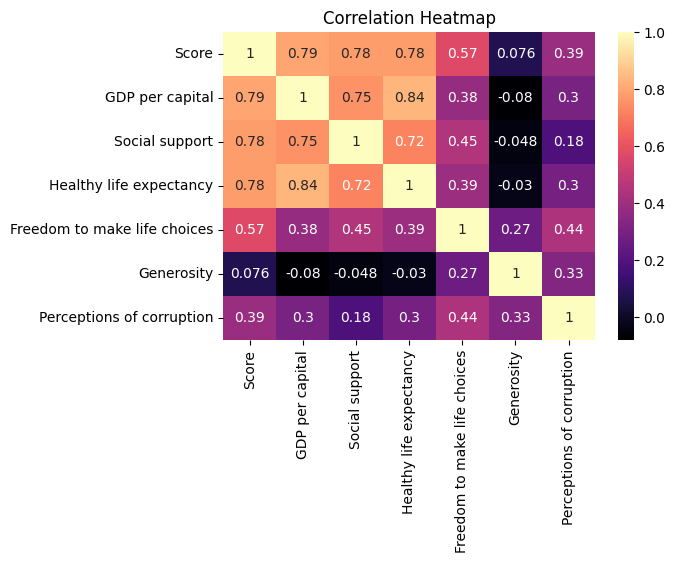

In [100]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="magma")
plt.title("Correlation Heatmap")
plt.show()

In [102]:
pivot_table_score = df.pivot_table(values='Score', index='Country or region', aggfunc='mean')
pivot_table_score = pivot_table_score.sort_values(by='Score', ascending=False)
display(pivot_table_score.head())

,Score
Country or region,
Finland,7.769
Denmark,7.600
Norway,7.554
Iceland,7.494
Netherlands,7.488


In [103]:
pivot_table_gdp = df.pivot_table(values='GDP per capital', index='Country or region', aggfunc='mean')
pivot_table_gdp = pivot_table_gdp.sort_values(by='GDP per capital', ascending=False)
display(pivot_table_gdp.head())

,GDP per capital
Country or region,
Qatar,1.684
Luxembourg,1.609
Singapore,1.572
United Arab Emirates,1.503
Kuwait,1.500


In [104]:
pivot_table_social_support = df.pivot_table(values='Social support', index='Country or region', aggfunc='mean')
pivot_table_social_support = pivot_table_social_support.sort_values(by='Social support', ascending=False)
display(pivot_table_social_support.head())

,Social support
Country or region,
Iceland,1.624
Finland,1.587
Norway,1.582
Denmark,1.573
New Zealand,1.557


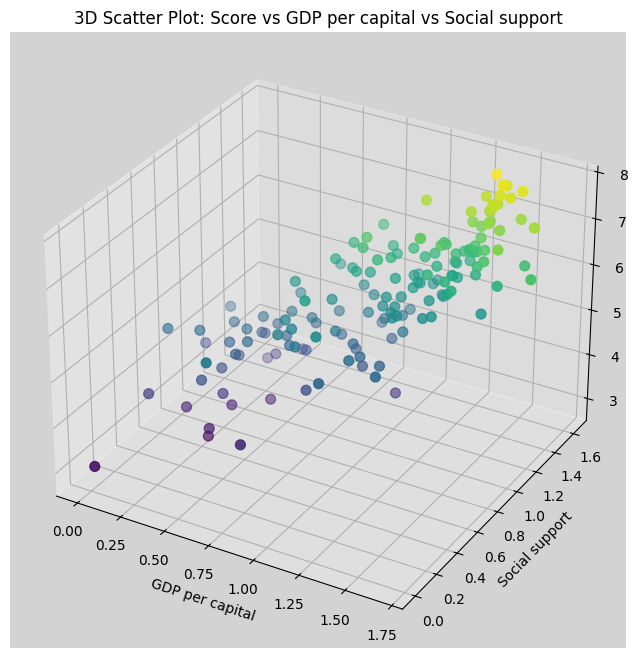

In [105]:
from mpl_toolkits.mplot3d import Axes3D


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = df['GDP per capital']
y = df['Social support']
z = df['Score']

# 3D scatter plot
ax.scatter(x, y, z, c=z, cmap='viridis', s=50)

ax.set_xlabel('GDP per capital')
ax.set_ylabel('Social support')
ax.set_zlabel('Score')
ax.set_title('3D Scatter Plot: Score vs GDP per capital vs Social support')

ax.set_facecolor('lightgray')

plt.show()

In [106]:
df.isnull().sum()

,0
Country or region,0
Score,0
GDP per capital,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


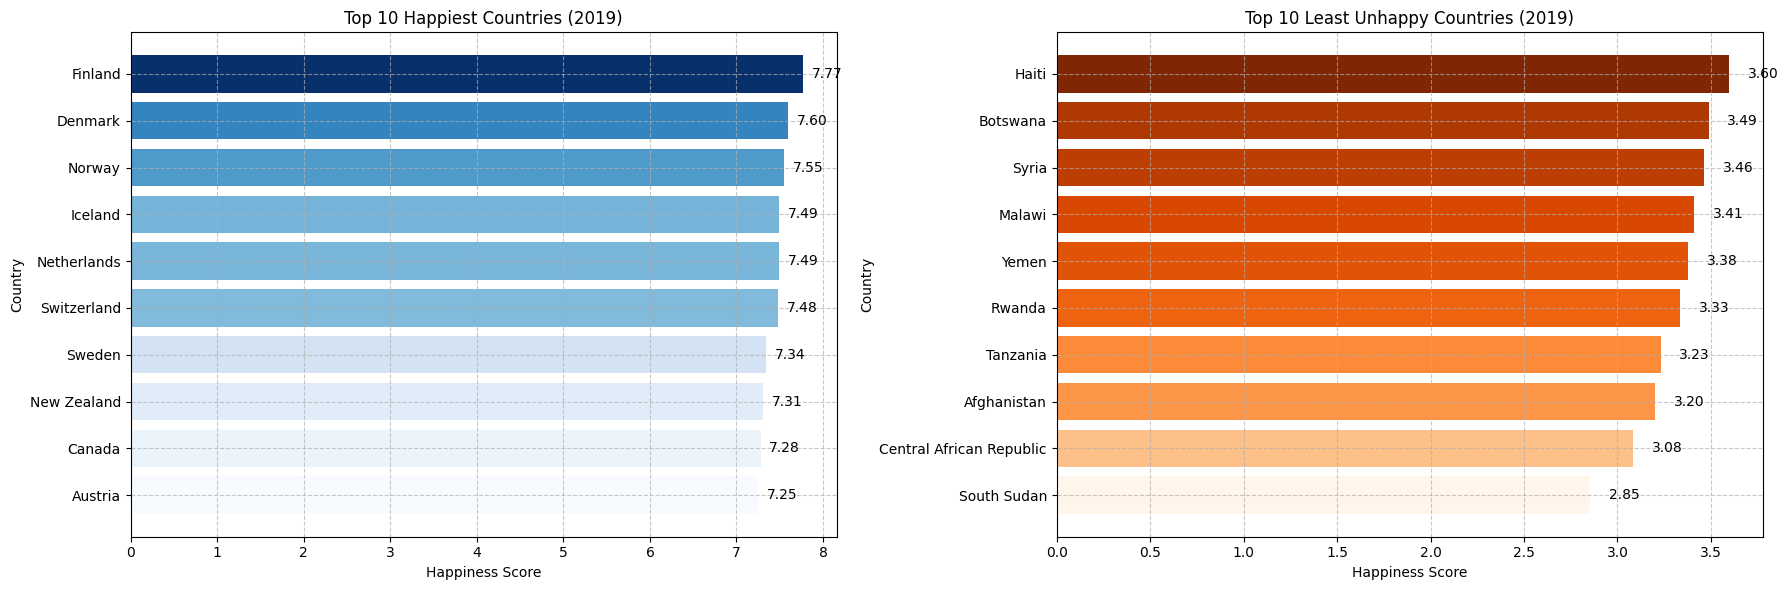

In [107]:
import matplotlib.cm as cm

top10 = df.sort_values("Score", ascending=False).head(10)

bottom10 = df.sort_values("Score", ascending=True).head(10)
bottom10 = bottom10.sort_values("Score", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18,6))

norm_top = (top10["Score"] - top10["Score"].min()) / (top10["Score"].max() - top10["Score"].min())
colors_top = [cm.Blues(x) for x in norm_top]

bars_top = axes[0].barh(top10["Country or region"], top10["Score"], color=colors_top)
axes[0].invert_yaxis()
axes[0].set_title("Top 10 Happiest Countries (2019)")
axes[0].set_xlabel("Happiness Score")
axes[0].set_ylabel("Country")

axes[0].grid(True, axis='x', linestyle='--', alpha=0.7)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)
for bar in bars_top:
    width = bar.get_width()
    axes[0].text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')


norm_bottom = (bottom10["Score"] - bottom10["Score"].min()) / (bottom10["Score"].max() - bottom10["Score"].min())
colors_bottom = [cm.Oranges(x) for x in norm_bottom]

bars_bottom = axes[1].barh(bottom10["Country or region"], bottom10["Score"], color=colors_bottom)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Least Unhappy Countries (2019)")
axes[1].set_xlabel("Happiness Score")
axes[1].set_ylabel("Country")

for bar in bars_bottom:
    width = bar.get_width()
    axes[1].text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')

plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **2. Feature Scaling and Encoding**

In [108]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1️⃣ Define numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# 2️⃣ Copy DataFrame for coding
df_encoded = df.copy()

# 3️⃣ One-Hot code
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = encoder.fit_transform(df_encoded[categorical_cols])

# Сreate new DataFrame
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_cols))

# 4️⃣ Concat numeric and caterorical columns
df_encoded = pd.concat([df_encoded.drop(columns=categorical_cols), one_hot_df], axis=1)

# 5️⃣ Numeric columns standartisation
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# 6️⃣ Result evaluation

df_encoded.head()

,Score,GDP per capital,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Country or region_Afghanistan,Country or region_Albania,Country or region_Algeria,...,Country or region_United Arab Emirates,Country or region_United Kingdom,Country or region_United States,Country or region_Uruguay,Country or region_Uzbekistan,Country or region_Venezuela,Country or region_Vietnam,Country or region_Yemen,Country or region_Zambia,Country or region_Zimbabwe
0,2.128711,1.095042,1.268098,1.080422,1.424282,-0.335404,2.996757,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.976397,1.203324,1.221154,1.121857,1.396277,0.707265,3.177158,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.934938,1.467734,1.251332,1.254446,1.473292,0.907373,2.444941,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.880862,1.195769,1.392163,1.246159,1.389276,1.781530,0.078500,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.875454,1.236060,1.050146,1.134287,1.151229,1.444506,1.988632,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [109]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Columns: 163 entries, Score to Country or region_Zimbabwe
dtypes: float64(163)
memory usage: 198.8 KB


In [110]:
country_columns = [col for col in df_encoded.columns if col.startswith('Country or region_')]
country_columns

['Country or region_Afghanistan',
 'Country or region_Albania',
 'Country or region_Algeria',
 'Country or region_Argentina',
 'Country or region_Armenia',
 'Country or region_Australia',
 'Country or region_Austria',
 'Country or region_Azerbaijan',
 'Country or region_Bahrain',
 'Country or region_Bangladesh',
 'Country or region_Belarus',
 'Country or region_Belgium',
 'Country or region_Benin',
 'Country or region_Bhutan',
 'Country or region_Bolivia',
 'Country or region_Bosnia and Herzegovina',
 'Country or region_Botswana',
 'Country or region_Brazil',
 'Country or region_Bulgaria',
 'Country or region_Burkina Faso',
 'Country or region_Burundi',
 'Country or region_Cambodia',
 'Country or region_Cameroon',
 'Country or region_Canada',
 'Country or region_Central African Republic',
 'Country or region_Chad',
 'Country or region_Chile',
 'Country or region_China',
 'Country or region_Colombia',
 'Country or region_Comoros',
 'Country or region_Congo (Brazzaville)',
 'Country or r

### **3. Data Splitting, Model Training, and Evaluation for Regression Tasks**

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [112]:
X = df_encoded.drop('Score', axis=1)
y = df_encoded['Score']

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((124, 162), (124,), (32, 162), (32,))

In [115]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# ---------------------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MSE': mse,
        'R2': r2
    })

# ---------------------------
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,MSE,R2
2,Gradient Boosting,0.266199,0.685107
1,Random Forest,0.295692,0.650220
0,Linear Regression,0.336523,0.601920


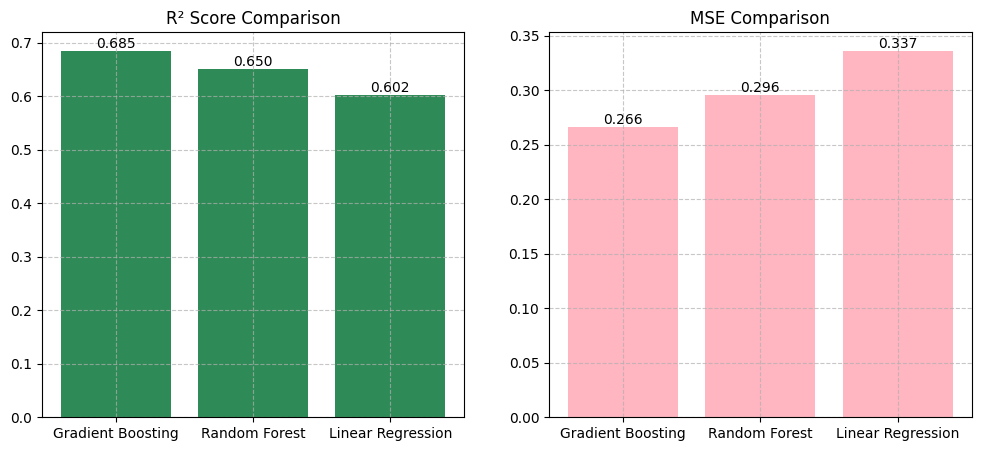

In [116]:
plt.figure(figsize=(12, 5))

# 🔹 R²
plt.subplot(1, 2, 1)
plt.bar(results_df['Model'], results_df['R2'], color='seagreen')
plt.title("R² Score Comparison")

plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# числа над точками
for x, y in zip(results_df['Model'], results_df['R2']):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

# 🔹 MSE
plt.subplot(1, 2, 2)
plt.bar(results_df['Model'], results_df['MSE'], color='lightpink')
plt.title("MSE Comparison")

plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# числа над точками
for x, y in zip(results_df['Model'], results_df['MSE']):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

plt.show()

### **Comparison of Initial Regression Models**

After training and evaluating three initial regression models, we can compare their performance based on Mean Squared Error (MSE) and R-squared (R2):

*   **Mean Squared Error (MSE):** This metric measures the average squared difference between the estimated values and the actual value. A lower MSE indicates a better fit of the model to the data.
*   **R-squared (R2):** Also known as the coefficient of determination, R2 represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R2 value (closer to 1) indicates that the model explains a larger proportion of the variance in the target variable.

Based on these initial results, the **Gradient Boosting** model currently shows the best performance with the lowest MSE 0.266 and highest R2 score 0.685, indicating it is the most effective at predicting the happiness score among the tested models without hyperparameter tuning.

### **4. Hyperparameters Tuning**

###### *GridSearch for RandomForest and Gradient Boosting*

In [117]:
from sklearn.model_selection import GridSearchCV

In [118]:
for estimator in range(50, 301, 50):
    model = RandomForestRegressor(
        n_estimators=estimator,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"n_estimators={estimator} | MSE={mse:.4f} | R²={r2:.4f}")

n_estimators=50 | MSE=0.2912 | R²=0.6555
n_estimators=100 | MSE=0.2957 | R²=0.6502
n_estimators=150 | MSE=0.2953 | R²=0.6507
n_estimators=200 | MSE=0.2934 | R²=0.6529
n_estimators=250 | MSE=0.2961 | R²=0.6497
n_estimators=300 | MSE=0.2996 | R²=0.6456


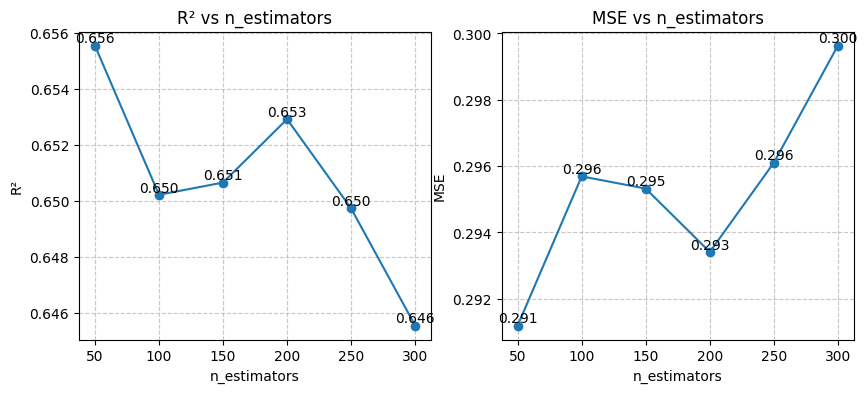

In [119]:
estimators = []
mse_list = []
r2_list = []

for estimator in range(50, 301, 50):
    model = RandomForestRegressor(
        n_estimators=estimator,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    estimators.append(estimator)
    mse_list.append(mse)
    r2_list.append(r2)


# ---------------------------
plt.figure(figsize=(10, 4))

# R²
plt.subplot(1, 2, 1)
plt.plot(estimators, r2_list, marker='o')
plt.title("R² vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("R²")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for x, y in zip(estimators, r2_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

# MSE
plt.subplot(1, 2, 2)
plt.plot(estimators, mse_list, marker='o')
plt.title("MSE vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("MSE")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for x, y in zip(estimators, mse_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

plt.show()

In [120]:
best_idx = r2_list.index(max(r2_list))
best_estimator = estimators[best_idx]
print("Best parameters:", best_estimator)

Best parameters: 50


In [121]:
for n in range(50, 401, 50):  # 50, 100, 150, ..., 400
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,  # fixing learning_rate
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"n_estimators={n} | MSE={mse:.4f} | R²={r2:.4f}")

n_estimators=50 | MSE=0.2678 | R²=0.6832
n_estimators=100 | MSE=0.2662 | R²=0.6851
n_estimators=150 | MSE=0.2667 | R²=0.6846
n_estimators=200 | MSE=0.2673 | R²=0.6838
n_estimators=250 | MSE=0.2677 | R²=0.6833
n_estimators=300 | MSE=0.2685 | R²=0.6824
n_estimators=350 | MSE=0.2691 | R²=0.6816
n_estimators=400 | MSE=0.2695 | R²=0.6811


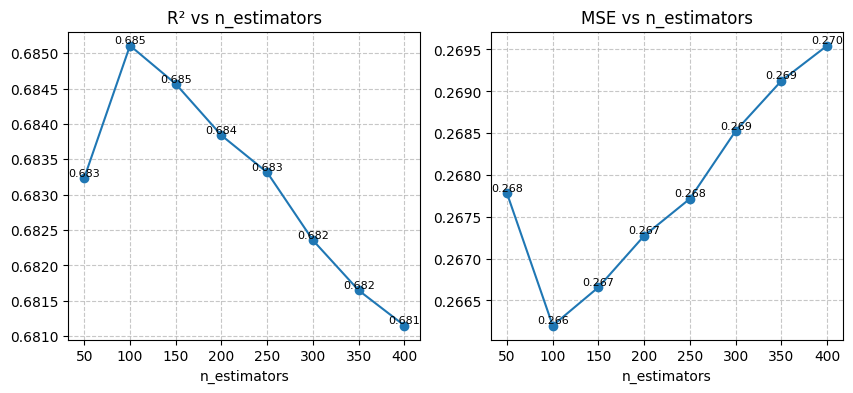

In [122]:
estimators = []
mse_list = []
r2_list = []

for n in range(50, 401, 50):   # 50,100,...,400
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    estimators.append(n)
    mse_list.append(mean_squared_error(y_test, y_pred))
    r2_list.append(r2_score(y_test, y_pred))

plt.figure(figsize=(10, 4))

# R²
plt.subplot(1, 2, 1)
plt.plot(estimators, r2_list, marker='o')
plt.title("R² vs n_estimators")
plt.xlabel("n_estimators")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for x, y in zip(estimators, r2_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

# MSE
plt.subplot(1, 2, 2)
plt.plot(estimators, mse_list, marker='o')
plt.title("MSE vs n_estimators")
plt.xlabel("n_estimators")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for x, y in zip(estimators, mse_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.show()

In [123]:
best_idx = r2_list.index(max(r2_list))
best_estimator = estimators[best_idx]
print("Best parameters:", best_estimator)

Best parameters: 100


### **Comparisson of Tuned Best Models**

In [124]:
results = []

# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
results.append({
    'Model': 'Linear Regression',
    'MSE': mean_squared_error(y_test, y_pred_lin),
    'R2': r2_score(y_test, y_pred_lin)
})

# Random Forest with best parameters (n_estimators=50, max_depth=None)
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append({
    'Model': 'Random Forest',
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf)
})

# Gradient Boosting with best parameters  (n_estimators=100, learning_rate=0.1)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
results.append({
    'Model': 'Gradient Boosting',
    'MSE': mean_squared_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb)
})


# ---------------------------
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df

,Model,MSE,R2
0,Linear Regression,0.3365,0.6019
1,Random Forest,0.2912,0.6555
2,Gradient Boosting,0.2662,0.6851


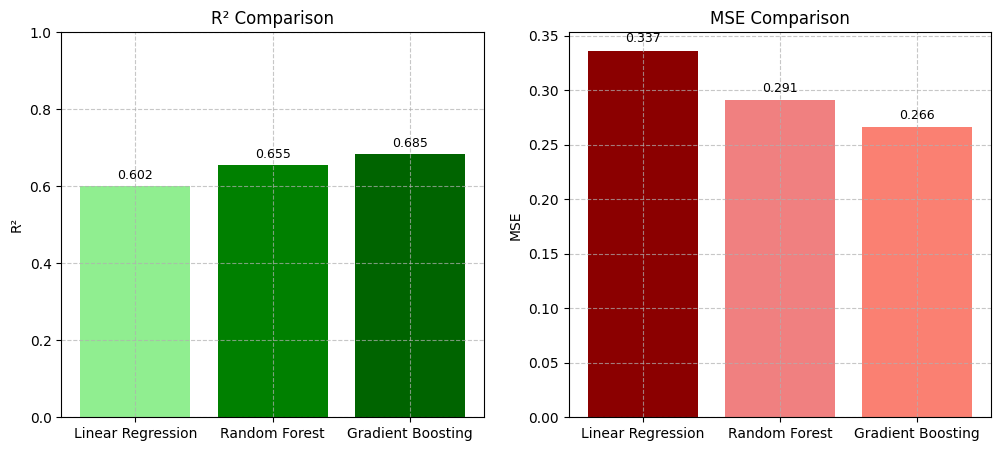

In [125]:
plt.figure(figsize=(12, 5))

# R²
plt.subplot(1, 2, 1)
plt.bar(results_df['Model'], results_df['R2'], color=['lightgreen','green','darkgreen'])
plt.title("R² Comparison")
plt.ylabel("R²")
plt.ylim(0, 1)

for i, r in enumerate(results_df['R2']):
    plt.text(i, r+0.01, f"{r:.3f}", ha='center', va='bottom', fontsize=9)

plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# MSE
plt.subplot(1, 2, 2)
plt.bar(results_df['Model'], results_df['MSE'], color=['darkred','lightcoral','salmon'])
plt.title("MSE Comparison")
plt.ylabel("MSE")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for i, r in enumerate(results_df['MSE']):
    plt.text(i, r+0.005, f"{r:.3f}", ha='center', va='bottom', fontsize=9)

plt.show()

#### **Summary after Regression Hyperparameter Tuning**

After performing hyperparameter tuning for the Random Forest and Gradient Boosting models, we observe that the overall performance metrics (MSE and R2) did not significantly change compared to their initial results. The **Gradient Boosting** model continues to demonstrate the best performance among all tested regression models, maintaining the lowest MSE and highest R2 score, even after optimization efforts.

# **Creating Categories for Classifications**

In [126]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [127]:
# Creating Target categories
df['Score_class'] = pd.cut(
    df['Score'],
    bins=[-float('inf'), 4.5, 6, float('inf')],  # интервалы
    labels=['Low', 'Medium', 'High']
)

# Count objects number
print(df['Score_class'].value_counts())

Score_class
Medium    69
High      52
Low       35
Name: count, dtype: int64


In [128]:
df.head()

,Country or region,Score,GDP per capital,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Score_class
0,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,High
1,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,High
2,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,High
3,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,High
4,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,High


In [129]:
df.drop('Score', axis=1, inplace=True)

In [130]:
# 1️⃣ Define numeric and categorical columns:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

target = 'Score_class'
if target in numeric_cols:
  numeric_cols.remove(target)
if target in categorical_cols:
  categorical_cols.remove(target)

# 2️⃣ Copy DataFrame for coding
df_encoded = df.copy()

# 3️⃣ One-Hot coding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = encoder.fit_transform(df_encoded[categorical_cols])

# Create new DataFrame
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_cols))

# 4️⃣ Concat new Columns
df_encoded = pd.concat([df_encoded.drop(columns=categorical_cols), one_hot_df], axis=1)

# 5️⃣ Standartisation
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# 6️⃣ Result check
df_encoded.head()

,GDP per capital,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Score_class,Country or region_Afghanistan,Country or region_Albania,Country or region_Algeria,...,Country or region_United Arab Emirates,Country or region_United Kingdom,Country or region_United States,Country or region_Uruguay,Country or region_Uzbekistan,Country or region_Venezuela,Country or region_Vietnam,Country or region_Yemen,Country or region_Zambia,Country or region_Zimbabwe
0,1.095042,1.268098,1.080422,1.424282,-0.335404,2.996757,High,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.203324,1.221154,1.121857,1.396277,0.707265,3.177158,High,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.467734,1.251332,1.254446,1.473292,0.907373,2.444941,High,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.195769,1.392163,1.246159,1.389276,1.781530,0.078500,High,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.236060,1.050146,1.134287,1.151229,1.444506,1.988632,High,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [131]:
le = LabelEncoder()
y = le.fit_transform(df_encoded[target])

In [132]:
X = df_encoded.drop(columns=[target])

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [134]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []

# Learning and evaluation
for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1_score': f1
    })

    print(f"\n{name}\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*40)

# Result table
results_df = pd.DataFrame(results).round(4)
results_df


Logistic Regression

              precision    recall  f1-score   support

        High       0.82      0.82      0.82        11
         Low       0.75      0.86      0.80         7
      Medium       0.77      0.71      0.74        14

    accuracy                           0.78        32
   macro avg       0.78      0.80      0.79        32
weighted avg       0.78      0.78      0.78        32

Confusion Matrix:
 [[ 9  0  2]
 [ 0  6  1]
 [ 2  2 10]]
----------------------------------------

Decision Tree

              precision    recall  f1-score   support

        High       1.00      0.73      0.84        11
         Low       0.50      0.57      0.53         7
      Medium       0.62      0.71      0.67        14

    accuracy                           0.69        32
   macro avg       0.71      0.67      0.68        32
weighted avg       0.73      0.69      0.70        32

Confusion Matrix:
 [[ 8  0  3]
 [ 0  4  3]
 [ 0  4 10]]
----------------------------------------

Rando

,Model,Accuracy,F1_score
0,Logistic Regression,0.7812,0.7803
1,Decision Tree,0.6875,0.6978
2,Random Forest,0.6562,0.6573
3,Gradient Boosting,0.5938,0.5961
4,KNN,0.6250,0.6008


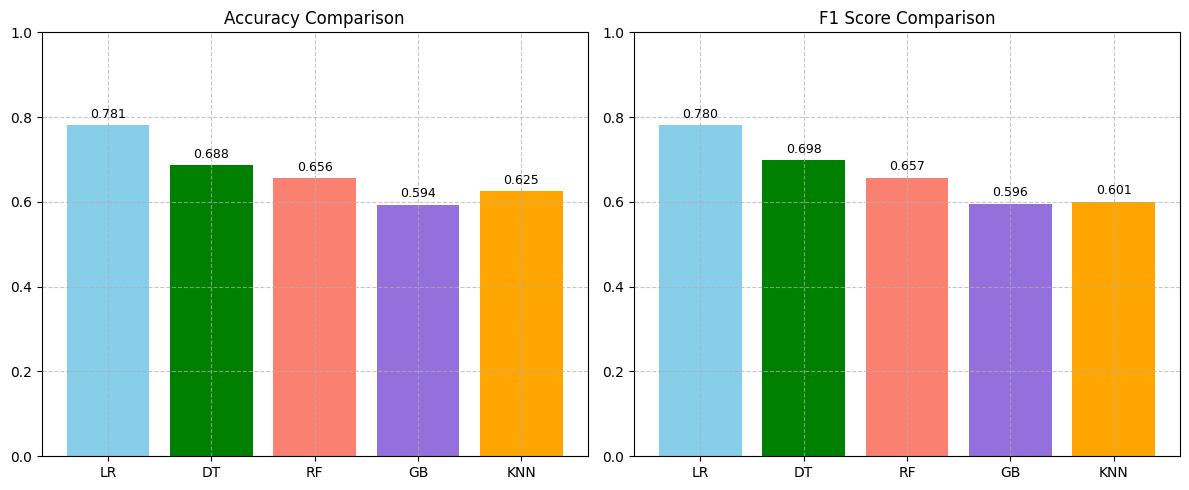

In [135]:
abbr_map = {
    'Logistic Regression': 'LR',
    'Decision Tree': 'DT',
    'Random Forest': 'RF',
    'Gradient Boosting': 'GB',
    'KNN': 'KNN'
}

results_df['Model_short'] = results_df['Model'].map(abbr_map)

plt.figure(figsize=(12, 5))


# Accuracy

plt.subplot(1, 2, 1)
plt.bar(results_df['Model_short'], results_df['Accuracy'],
        color=['skyblue','green','salmon','mediumpurple','orange'])

plt.title("Accuracy Comparison")
plt.ylim(0, 1)

plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9)


# F1 Score

plt.subplot(1, 2, 2)
plt.bar(results_df['Model_short'], results_df['F1_score'],
        color=['skyblue','green','salmon','mediumpurple','orange'])

plt.title("F1 Score Comparison")
plt.ylim(0, 1)

plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(results_df['F1_score']):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [136]:
results_df = results_df.sort_values('F1_score', ascending=False)
results_df

,Model,Accuracy,F1_score,Model_short
0,Logistic Regression,0.7812,0.7803,LR
1,Decision Tree,0.6875,0.6978,DT
2,Random Forest,0.6562,0.6573,RF
4,KNN,0.6250,0.6008,KNN
3,Gradient Boosting,0.5938,0.5961,GB


### **Comparison of Initial Classification Models**

After training and evaluating five initial classification models, we can compare their performance based on Accuracy and F1-score:

*   **Accuracy:** This metric measures the proportion of correctly classified instances out of the total number of instances. It's a good general measure, especially when classes are balanced.
*   **F1-score:** This is the harmonic mean of Precision and Recall. It's particularly useful when dealing with imbalanced datasets, as it provides a balance between these two metrics and is more robust than accuracy alone.

Here are the initial results for each model:

*   **Logistic Regression:** Accuracy = 0.7812, F1-score = 0.7803
*   **Decision Tree:** Accuracy = 0.6875, F1-score = 0.6978
*   **Random Forest:** Accuracy = 0.6562, F1-score = 0.6573
*   **KNN:** Accuracy = 0.6250, F1-score = 0.6008
*   **Gradient Boosting:** Accuracy = 0.5938, F1-score = 0.5961

Based on these initial results, **Logistic Regression** shows the best performance with the highest Accuracy (0.7812) and F1-score (0.7803) among the tested classification models before hyperparameter tuning. This suggests it is currently the most effective at predicting the happiness classes.

### **Hyperparameters Tuning GridSearchCV**

In [137]:
C_values = []
acc_list = []
f1_list = []

for C in [0.01, 0.1, 1, 10, 100]:

    model = LogisticRegression(
        C=C,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    C_values.append(C)
    acc_list.append(acc)
    f1_list.append(f1)

    print(f"C={C} | Accuracy={acc:.4f} | F1={f1:.4f}")

C=0.01 | Accuracy=0.6250 | F1=0.6083
C=0.1 | Accuracy=0.6875 | F1=0.6885
C=1 | Accuracy=0.7812 | F1=0.7803
C=10 | Accuracy=0.7500 | F1=0.7482
C=100 | Accuracy=0.7500 | F1=0.7482


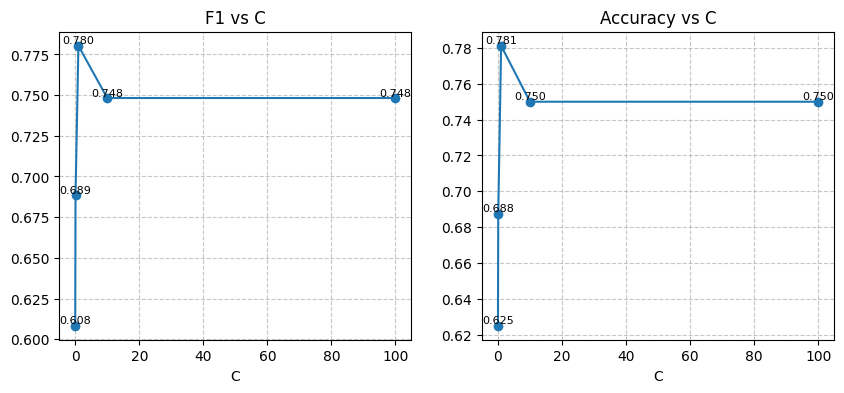

In [138]:
plt.figure(figsize=(10, 4))

#  F1-score
plt.subplot(1, 2, 1)
plt.plot(C_values, f1_list, marker='o')
plt.title("F1 vs C")
plt.xlabel("C")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for x, y in zip(C_values, f1_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

#  Accuracy
plt.subplot(1, 2, 2)
plt.plot(C_values, acc_list, marker='o')
plt.title("Accuracy vs C")
plt.xlabel("C")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for x, y in zip(C_values, acc_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.show()

In [139]:
best_idx = f1_list.index(max(f1_list))
best_C = C_values[best_idx]

print("\nBest C:", best_C)
print("Best F1:", f1_list[best_idx])
print("Best Accuracy:", acc_list[best_idx])


Best C: 1
Best F1: 0.7803240740740741
Best Accuracy: 0.78125


In [140]:
estimators = []   # n_estimators
acc_list = []     # Accuracy
f1_list = []      # F1-score

for n in range(50, 401, 50):   # 50, 100, ..., 400
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    estimators.append(n)
    acc_list.append(accuracy_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred, average='weighted'))

    print(f"n_estimators={n} | Accuracy={acc_list[-1]:.4f} | F1={f1_list[-1]:.4f}")

n_estimators=50 | Accuracy=0.5938 | F1=0.5961
n_estimators=100 | Accuracy=0.6562 | F1=0.6573
n_estimators=150 | Accuracy=0.6562 | F1=0.6573
n_estimators=200 | Accuracy=0.6562 | F1=0.6573
n_estimators=250 | Accuracy=0.6562 | F1=0.6573
n_estimators=300 | Accuracy=0.6562 | F1=0.6573
n_estimators=350 | Accuracy=0.6562 | F1=0.6573
n_estimators=400 | Accuracy=0.6562 | F1=0.6573


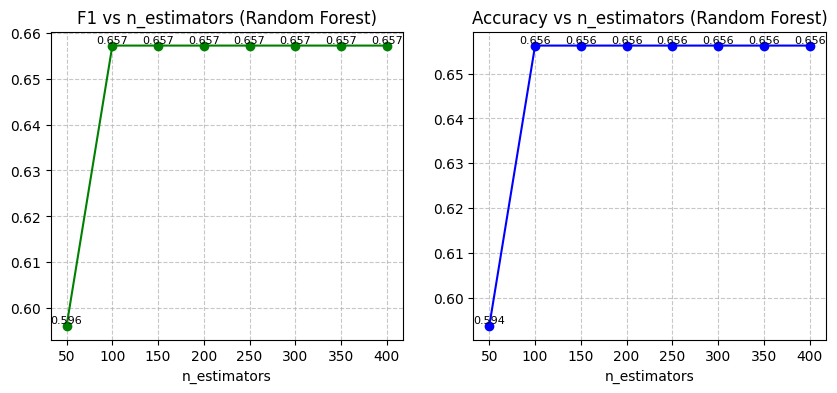

In [141]:
plt.figure(figsize=(10, 4))

#  F1-score
plt.subplot(1, 2, 1)
plt.plot(estimators, f1_list, marker='o', color='green')
plt.title("F1 vs n_estimators (Random Forest)")
plt.xlabel("n_estimators")
plt.grid(True, linestyle='--', alpha=0.7)
for x, y in zip(estimators, f1_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

#  Accuracy
plt.subplot(1, 2, 2)
plt.plot(estimators, acc_list, marker='o', color='blue')
plt.title("Accuracy vs n_estimators (Random Forest)")
plt.xlabel("n_estimators")
plt.grid(True, linestyle='--', alpha=0.7)
for x, y in zip(estimators, acc_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.show()

In [142]:
best_idx = f1_list.index(max(f1_list))
best_estimator = estimators[best_idx]

print("\nBest n_estimators:", best_estimator)
print("Best F1:", f1_list[best_idx])
print("Best Accuracy:", acc_list[best_idx])


Best n_estimators: 100
Best F1: 0.657258064516129
Best Accuracy: 0.65625


In [143]:
from sklearn.tree import DecisionTreeClassifier

depths = []
acc_list = []
f1_list = []

for d in range(1, 15):

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    depths.append(d)
    acc_list.append(accuracy_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred, average='weighted'))

    print(f"depth={d} | Accuracy={acc_list[-1]:.4f} | F1={f1_list[-1]:.4f}")

depth=1 | Accuracy=0.6250 | F1=0.5526
depth=2 | Accuracy=0.6875 | F1=0.6861
depth=3 | Accuracy=0.6875 | F1=0.6861
depth=4 | Accuracy=0.6250 | F1=0.6338
depth=5 | Accuracy=0.6562 | F1=0.6572
depth=6 | Accuracy=0.6562 | F1=0.6572
depth=7 | Accuracy=0.6562 | F1=0.6572
depth=8 | Accuracy=0.6250 | F1=0.6328
depth=9 | Accuracy=0.6875 | F1=0.6978
depth=10 | Accuracy=0.6875 | F1=0.6978
depth=11 | Accuracy=0.6875 | F1=0.6978
depth=12 | Accuracy=0.6875 | F1=0.6978
depth=13 | Accuracy=0.6875 | F1=0.6978
depth=14 | Accuracy=0.6875 | F1=0.6978


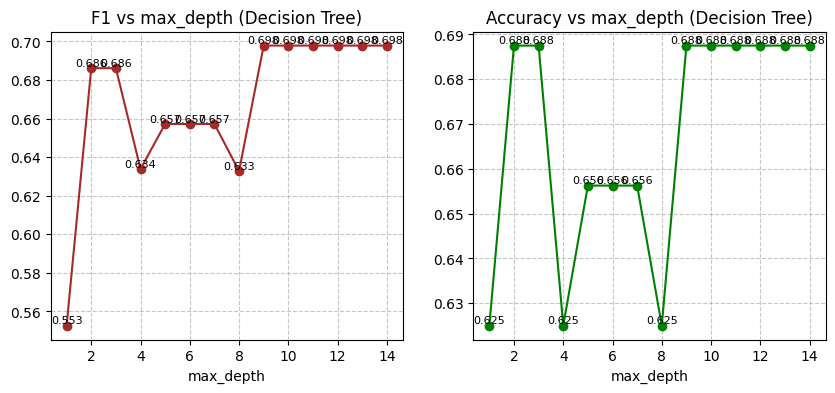

In [144]:
plt.figure(figsize=(10, 4))

#  F1
plt.subplot(1, 2, 1)
plt.plot(depths, f1_list, marker='o', color='brown')
plt.title("F1 vs max_depth (Decision Tree)")
plt.xlabel("max_depth")
plt.grid(True, linestyle='--', alpha=0.7)

for x, y in zip(depths, f1_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(depths, acc_list, marker='o', color='green')
plt.title("Accuracy vs max_depth (Decision Tree)")
plt.xlabel("max_depth")
plt.grid(True, linestyle='--', alpha=0.7)

for x, y in zip(depths, acc_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.show()

In [145]:
best_idx = f1_list.index(max(f1_list))
best_depth = depths[best_idx]

print("\nBest max_depth:", best_depth)
print("Best F1:", f1_list[best_idx])
print("Best Accuracy:", acc_list[best_idx])


Best max_depth: 9
Best F1: 0.6978070175438597
Best Accuracy: 0.6875


In [146]:
estimators = []
acc_list = []
f1_list = []

for n in range(50, 401, 50):   # 50, 100, ..., 400
    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    estimators.append(n)
    acc_list.append(accuracy_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred, average='weighted'))

    print(f"n_estimators={n} | Accuracy={acc_list[-1]:.4f} | F1={f1_list[-1]:.4f}")

n_estimators=50 | Accuracy=0.6250 | F1=0.6254
n_estimators=100 | Accuracy=0.6250 | F1=0.6254
n_estimators=150 | Accuracy=0.6250 | F1=0.6276
n_estimators=200 | Accuracy=0.5938 | F1=0.5961
n_estimators=250 | Accuracy=0.5625 | F1=0.5646
n_estimators=300 | Accuracy=0.5625 | F1=0.5646
n_estimators=350 | Accuracy=0.5625 | F1=0.5646
n_estimators=400 | Accuracy=0.5625 | F1=0.5646


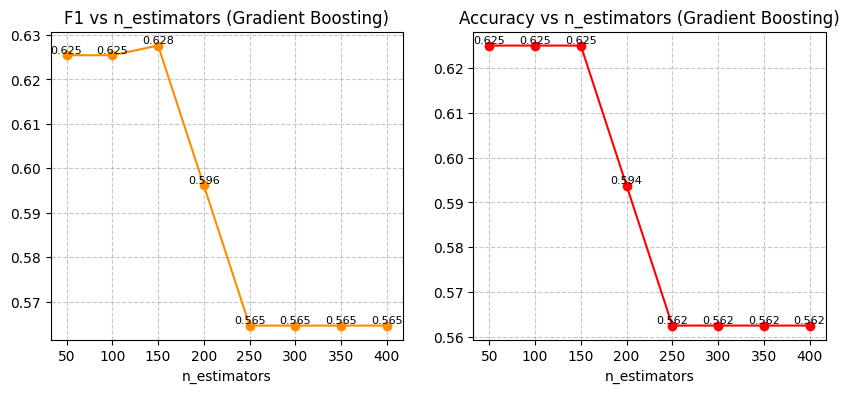

In [147]:
plt.figure(figsize=(10, 4))

#  F1
plt.subplot(1, 2, 1)
plt.plot(estimators, f1_list, marker='o', color='darkorange')
plt.title("F1 vs n_estimators (Gradient Boosting)")
plt.xlabel("n_estimators")
plt.grid(True, linestyle='--', alpha=0.7)

for x, y in zip(estimators, f1_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

#  Accuracy
plt.subplot(1, 2, 2)
plt.plot(estimators, acc_list, marker='o', color='red')
plt.title("Accuracy vs n_estimators (Gradient Boosting)")
plt.xlabel("n_estimators")
plt.grid(True, linestyle='--', alpha=0.7)

for x, y in zip(estimators, acc_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.show()

In [148]:
best_idx = f1_list.index(max(f1_list))
best_estimator = estimators[best_idx]

print("\nBest n_estimators:", best_estimator)
print("Best F1:", f1_list[best_idx])
print("Best Accuracy:", acc_list[best_idx])


Best n_estimators: 150
Best F1: 0.6276041666666666
Best Accuracy: 0.625


In [149]:
neighbors = []
acc_list = []
f1_list = []

for k in range(1, 31):   # k = 1…30
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    neighbors.append(k)
    acc_list.append(accuracy_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred, average='weighted'))

    print(f"k={k} | Accuracy={acc_list[-1]:.4f} | F1={f1_list[-1]:.4f}")

k=1 | Accuracy=0.6250 | F1=0.6008
k=2 | Accuracy=0.5625 | F1=0.4886
k=3 | Accuracy=0.6250 | F1=0.6121
k=4 | Accuracy=0.5938 | F1=0.5591
k=5 | Accuracy=0.6250 | F1=0.6008
k=6 | Accuracy=0.6250 | F1=0.6008
k=7 | Accuracy=0.6875 | F1=0.6788
k=8 | Accuracy=0.7500 | F1=0.7456
k=9 | Accuracy=0.7812 | F1=0.7737
k=10 | Accuracy=0.6562 | F1=0.6486
k=11 | Accuracy=0.7500 | F1=0.7456
k=12 | Accuracy=0.7188 | F1=0.7169
k=13 | Accuracy=0.6875 | F1=0.6800
k=14 | Accuracy=0.6875 | F1=0.6849
k=15 | Accuracy=0.7188 | F1=0.7075
k=16 | Accuracy=0.7188 | F1=0.7075
k=17 | Accuracy=0.7188 | F1=0.7075
k=18 | Accuracy=0.7812 | F1=0.7788
k=19 | Accuracy=0.7188 | F1=0.7075
k=20 | Accuracy=0.7812 | F1=0.7788
k=21 | Accuracy=0.6875 | F1=0.6656
k=22 | Accuracy=0.7500 | F1=0.7456
k=23 | Accuracy=0.7500 | F1=0.7448
k=24 | Accuracy=0.6875 | F1=0.6795
k=25 | Accuracy=0.7500 | F1=0.7448
k=26 | Accuracy=0.7812 | F1=0.7788
k=27 | Accuracy=0.7500 | F1=0.7396
k=28 | Accuracy=0.7188 | F1=0.7113
k=29 | Accuracy=0.8125 | F1=0

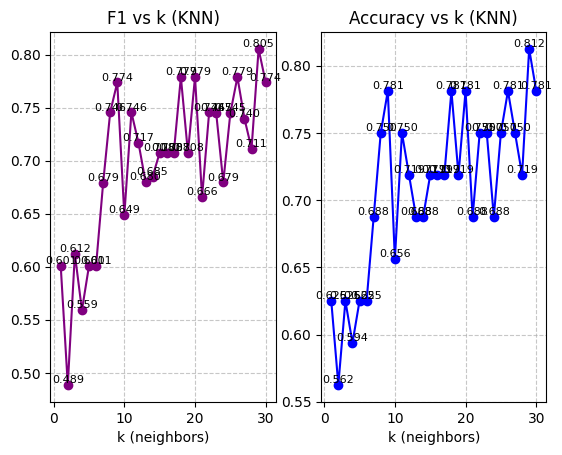

In [150]:
#  F1
plt.subplot(1, 2, 1)
plt.plot(neighbors, f1_list, marker='o', color='purple')
plt.title("F1 vs k (KNN)")
plt.xlabel("k (neighbors)")
plt.grid(True, linestyle='--', alpha=0.7)

for x, y in zip(neighbors, f1_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

#  Accuracy
plt.subplot(1, 2, 2)
plt.plot(neighbors, acc_list, marker='o', color='blue')
plt.title("Accuracy vs k (KNN)")
plt.xlabel("k (neighbors)")
plt.grid(True, linestyle='--', alpha=0.7)

for x, y in zip(neighbors, acc_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.show()

In [151]:
best_idx = f1_list.index(max(f1_list))
best_k = neighbors[best_idx]

print("\nBest k:", best_k)
print("Best F1:", f1_list[best_idx])
print("Best Accuracy:", acc_list[best_idx])


Best k: 29
Best F1: 0.805340909090909
Best Accuracy: 0.8125


In [152]:
tuned_models = {
    'LR': LogisticRegression(C=1, max_iter=1000),
    'DT': DecisionTreeClassifier(max_depth=9, random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=29)
}

tuned_results = []

for name, model in tuned_models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    tuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'F1_score': f1
    })

tuned_df = pd.DataFrame(tuned_results).round(4)
tuned_df

,Model,Accuracy,F1_score
0,LR,0.7812,0.7803
1,DT,0.6875,0.6978
2,RF,0.6562,0.6573
3,GB,0.6250,0.6276
4,KNN,0.8125,0.8053


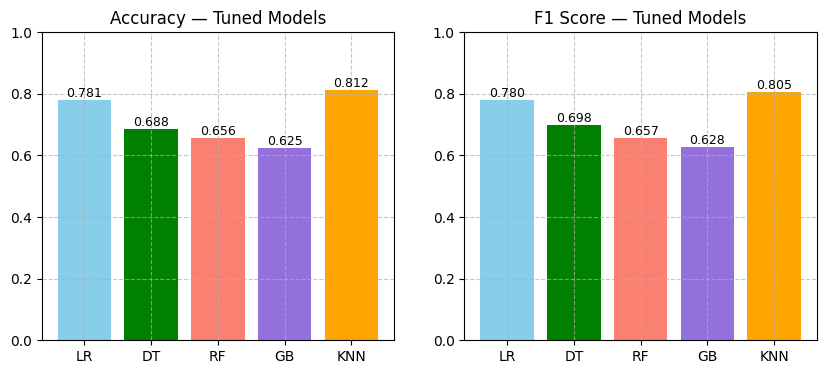

In [153]:
plt.figure(figsize=(10, 4))


# Accuracy

plt.subplot(1, 2, 1)

plt.bar(tuned_df['Model'], tuned_df['Accuracy'],
        color=['skyblue','green','salmon','mediumpurple','orange'])

plt.title("Accuracy — Tuned Models")
plt.ylim(0, 1)

plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(tuned_df['Accuracy']):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', fontsize=9)


# F1 Score

plt.subplot(1, 2, 2)

plt.bar(tuned_df['Model'], tuned_df['F1_score'],
        color=['skyblue','green','salmon','mediumpurple','orange'])

plt.title("F1 Score — Tuned Models")
plt.ylim(0, 1)

plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(tuned_df['F1_score']):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', fontsize=9)

plt.show()

In [154]:
knn_model_tuned = KNeighborsClassifier(n_neighbors=29)
knn_model_tuned.fit(X_train, y_train)
y_pred_knn = knn_model_tuned.predict(X_test)
print("Confusion Matrix for Tuned KNN Model:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report for Tuned KNN Model:\n", classification_report(y_test, y_pred_knn, target_names=le.classes_))

Confusion Matrix for Tuned KNN Model:
 [[11  0  0]
 [ 0  4  3]
 [ 3  0 11]]

Classification Report for Tuned KNN Model:
               precision    recall  f1-score   support

        High       0.79      1.00      0.88        11
         Low       1.00      0.57      0.73         7
      Medium       0.79      0.79      0.79        14

    accuracy                           0.81        32
   macro avg       0.86      0.79      0.80        32
weighted avg       0.83      0.81      0.81        32



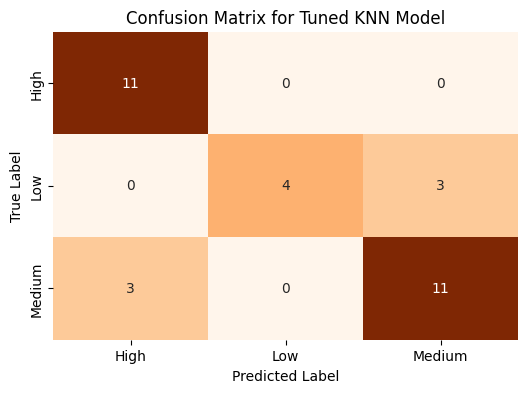

In [155]:
cm = confusion_matrix(y_test, y_pred_knn)
class_labels = le.classes_

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned KNN Model')
plt.show()

### **Interpretation of Tuned KNN Model Performance**

The tuned K-Nearest Neighbors (KNN) model, identified as the best classification model, shows strong overall performance with an Accuracy of **0.81** and a weighted F1-score of **0.81**. Analyzing its Confusion Matrix and Classification Report reveals the following:

*   **High Happiness Score (Class 'High'):** The model excels at identifying countries with high happiness scores. All 11 actual 'High' instances were correctly classified, resulting in a perfect Recall of 1.00 for this class.

*   **Low Happiness Score (Class 'Low'):** For the 'Low' class, the model demonstrates high Precision (1.00), meaning that when it predicts 'Low', it is always correct. However, its Recall is lower (0.57), indicating that it misses some of the actual 'Low' instances (3 out of 7 were misclassified as 'Medium'). This suggests the model is somewhat conservative in predicting the 'Low' category.

*   **Medium Happiness Score (Class 'Medium'):** The model shows balanced performance for the 'Medium' class, correctly classifying 11 out of 14 instances. There are 3 instances that were actually 'Medium' but were incorrectly predicted as 'High'.

**In summary:** The tuned KNN model is robust overall, particularly strong in identifying high happiness countries. While highly precise for low happiness scores, it sometimes fails to recall all low instances, misclassifying them as medium. It also shows a slight tendency to misclassify some medium happiness countries as high.

# **Final Summary after Classification Hyperparameter Tuning**

After performing hyperparameter tuning for all classification models, we have a clearer picture of their optimized performance:

*   **Logistic Regression (LR):** Accuracy = 0.7812, F1-score = 0.7803
*   **Decision Tree (DT):** Accuracy = 0.6875, F1-score = 0.6978
*   **Random Forest (RF):** Accuracy = 0.6562, F1-score = 0.6573
*   **Gradient Boosting (GB):** Accuracy = 0.6250, F1-score = 0.6276
*   **K-Nearest Neighbors (KNN):** Accuracy = 0.8125, F1-score = 0.8053

Comparing these results, the **K-Nearest Neighbors (KNN) model** now stands out as the best performer among all tested classification models after hyperparameter tuning. It achieved the highest Accuracy of **0.8125** and the highest F1-score of **0.8053**, demonstrating its superior ability to predict the happiness categories ('Low', 'Medium', 'High'). Interestingly, the tuning significantly improved KNN's performance, making it surpass Logistic Regression, which was the best before tuning.